<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/Linear-model-for-regression/Multioutput_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

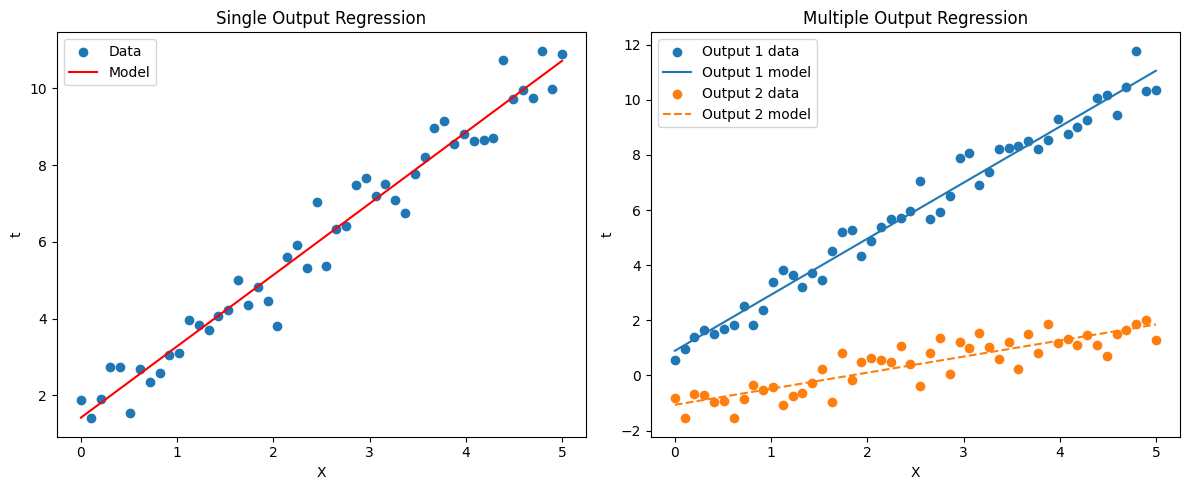

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate data
# -----------------------------
np.random.seed(0)

N = 50
X = np.linspace(0, 5, N)

# Design matrix (basis function: [1, x])
Phi = np.vstack([np.ones(N), X]).T   # shape (N, 2)

# -----------------------------
# 2. SINGLE OUTPUT
# -----------------------------
true_w = np.array([1.0, 2.0])   # y = 1 + 2x
t_single = Phi @ true_w + np.random.normal(0, 0.5, N)

# Compute weights (ML solution)
w_ml = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ t_single

y_single_pred = Phi @ w_ml

# -----------------------------
# 3. MULTIPLE OUTPUT
# -----------------------------
# Two different target functions
true_W = np.array([
    [1.0, -1.0],   # bias terms
    [2.0,  0.5]    # slopes
])  # shape (2, 2)

T_multi = Phi @ true_W + np.random.normal(0, 0.5, (N, 2))

# Compute W (ML solution)
W_ml = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ T_multi

Y_multi_pred = Phi @ W_ml

# -----------------------------
# 4. PLOTTING
# -----------------------------
plt.figure(figsize=(12, 5))

# ---- Single output ----
plt.subplot(1, 2, 1)
plt.scatter(X, t_single, label="Data")
plt.plot(X, y_single_pred, color='red', label="Model")
plt.title("Single Output Regression")
plt.xlabel("X")
plt.ylabel("t")
plt.legend()

# ---- Multiple output ----
plt.subplot(1, 2, 2)

# First output
plt.scatter(X, T_multi[:, 0], label="Output 1 data")
plt.plot(X, Y_multi_pred[:, 0], label="Output 1 model")

# Second output
plt.scatter(X, T_multi[:, 1], label="Output 2 data")
plt.plot(X, Y_multi_pred[:, 1], linestyle='--', label="Output 2 model")

plt.title("Multiple Output Regression")
plt.xlabel("X")
plt.ylabel("t")
plt.legend()

plt.tight_layout()
plt.show()